# **Módulo 5: Modelos Avançados e Comparação - Exercicío Prático**
---

Neste exercício, exploraremos **modelos avançados de regressão** e como realizar uma **comparação** justa entre eles. Você irá treinar, avaliar e comparar o desempenho de diferentes algoritmos, analisando como a configuração de seus hiperparâmetros impacta as previsões sobre o dataset de preços de casas (housing_tratado.csv).

1. **Execute a primeira célula** para carregar o dataset.
2. Siga as instruções ao longo do notebook — os **comentários nas células indicam exatamente o que deve ser feito**, e os locais onde você deve preencher o código estarão claramente marcados com `'aqui'`, para facilitar o processo.
3. No final, utilize os resultados obtidos para responder às perguntas no espaço indicado no material do curso.


Execute a célula abaixo para começar.

## **Carregamento de Dados e Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/TreinamentoICCInatel/Curso_Regressao_na_Pratica/refs/heads/main/Arquivos/housing_tratado.csv"
housing = pd.read_csv(url)

# Use o comando head para verificar se o dataset foi carregado corretamente

In [2]:
X = housing.drop("median_house_value", axis=1)
y = housing["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Modelo treinado. Pronto para avaliação.")

Modelo treinado. Pronto para avaliação.


## **Criando uma Árvore de Decisão**

Nesta etapa, iremos treinar o modelo de regressão e gerar um gráfico de análise comparando os valores reais com os valores preditos. Para isso, importe a classe `DecisionTreeRegressor` e configure o parâmetro `max_depth` para que a árvore tenha profundidade igual a cinco.

In [ ]:
# Importe a biblioteca e ajuste o parâmetro conforme solicitado
from sklearn.tree import 'aqui'
dt = DecisionTreeRegressor(max_depth='aqui', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

#### **Gerando visualização**

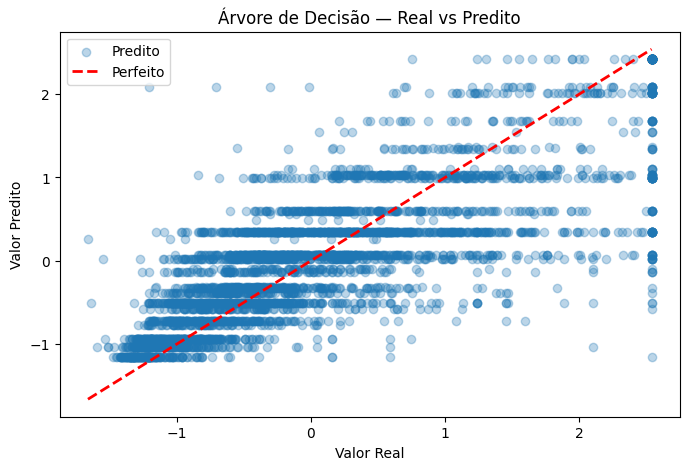

In [14]:
# O gráfico deste bloco de código será exibido após a execução correta das etapas/instruções acima.
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_dt, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("Árvore de Decisão — Real vs Predito")
plt.show()

**1. Com base na distribuição dos pontos no gráfico, qual das alternativas apresenta a interpretação mais adequada sobre o comportamento do modelo?**

a) O modelo apresenta excelente desempenho, pois a maioria dos pontos coincide exatamente com a linha tracejada, indicando ausência de erro nas previsões.

b) O modelo não conseguiu aprender nenhum padrão dos dados, já que os pontos estão totalmente aleatórios e não seguem qualquer tendência em relação aos valores reais.

c) O modelo consegue capturar a tendência geral de crescimento entre valores reais e preditos, porém apresenta erros consideráveis e produz previsões em níveis constantes (em “degraus”), demonstrando falta de refinamento nas previsões.

d) O modelo está claramente superajustado (overfitting), pois as previsões variam de forma extremamente sensível, gerando uma curva contínua e altamente complexa.

(correta c)

## **Aplicando o Random Forest Regressor**

Na célula a seguir será gerado o gráfico utilizado de exemplo no notebook no módulo 5

#### **Gerando Visualização**

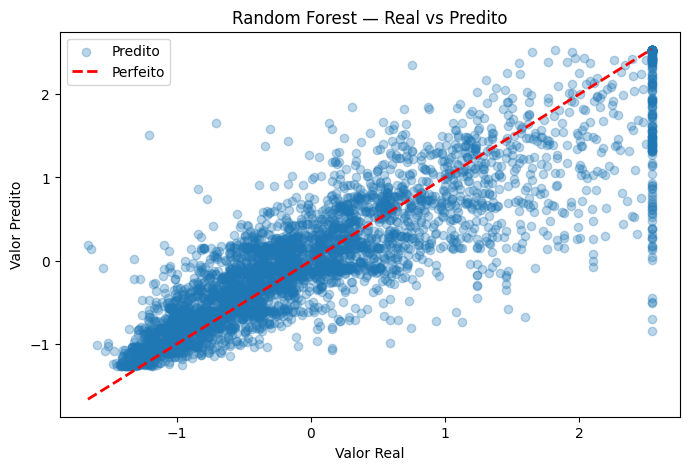

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("Random Forest — Real vs Predito")
plt.show()

Ajuste os parâmetros do `RandomForestRegressor` para metade dos valores utilizados no exemplo anterior, ou seja, definindo um `n_estimators` que gere no máximo 100 árvores e um `max_depth` igual a 4.

In [10]:
rf = RandomForestRegressor(
    n_estimators= 'aqui',
    max_depth= 'aqui',
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#### **Gerando Visualização**

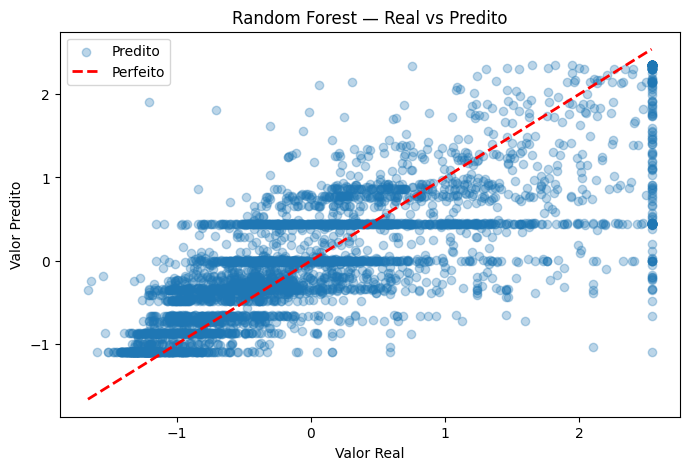

In [11]:
# O gráfico deste bloco de código será exibido após a execução correta das etapas/instruções acima.
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("Random Forest — Real vs Predito")
plt.show()

#### **2. Quais foram os principais efeitos da redução dos hiperparâmetros (n_estimators e max_depth) no desempenho do modelo?**

a) O segundo modelo apresentou maior dispersão dos pontos, previsões mais “achatadas” (menor variação nos valores preditos) e possível aumento de underfitting devido à menor complexidade.

b) O segundo modelo apresentou maior aproximação da linha ideal, indicando aumento da precisão e melhor capacidade de generalização.

c) A redução dos parâmetros não causou nenhuma alteração perceptível no comportamento das previsões.

d) O segundo modelo passou a apresentar overfitting mais evidente, com pontos excessivamente colados à linha ideal.

(correta a)

## **Treinando o SVR com diferentes graus polinomiais**

Na célula a seguir, será gerado o gráfico que apresenta a comparação entre os valores reais e os valores preditos a partir da aplicação do SVR polinomial de grau 2, utilizado como exemplo no notebook anterior.

    ⚠️ As próximas células — especialmente a do exercício proposto — podem levar mais tempo que o habitual para serem processadas.

#### **Gerando Visualização**

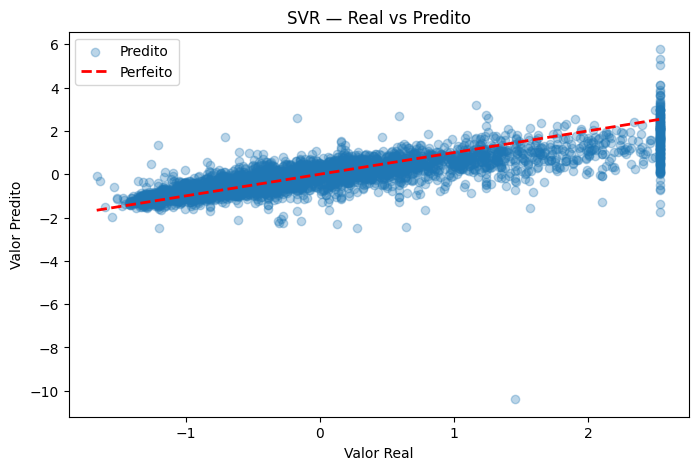

In [8]:
from sklearn.svm import SVR

svr = SVR(kernel="poly", degree= 2, C=10, epsilon=0.1)
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_svr, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("SVR — Real vs Predito")
plt.show()

Modifique o grau polinomial do SVR de 2 para 3, com o objetivo de analisar o impacto dessa alteração nas predições do modelo.

In [4]:
svr = SVR(kernel="poly", degree= 'aqui', C=10, epsilon=0.1)
svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

#### **Gerando Visualização**

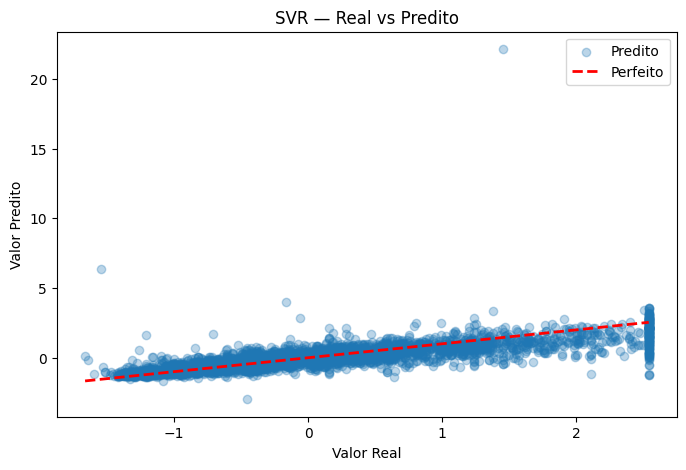

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_svr, alpha=0.3, label="Predito")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label="Perfeito")
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.legend()
plt.title("SVR — Real vs Predito")
plt.show()

#### **3. O que o aumento do grau de 2 para 3 acarretou no desempenho do modelo?**

a) Houve melhora no desempenho, pois o aumento da complexidade permitiu melhor ajuste aos dados, o que tende a reduzir métricas de erro como RMSE e MAE.

b) Houve piora no desempenho, pois o aumento da complexidade elevou a variância do modelo, gerando maior dispersão nas previsões e possível aumento nas métricas de erro.

c) O desempenho permaneceu inalterado, pois o grau do polinômio não influencia significativamente o comportamento do SVR.

d) O aumento do grau reduziu a complexidade do modelo, tornando-o mais robusto e menos sensível a ruídos.

(correta b)

## **Processo de análise e seleção de modelos**

Durante a comparação entre diferentes modelos de regressão, um analista decidiu:

- Utilizar métricas diferentes para cada modelo

- Treinar cada modelo com subconjuntos de dados levemente diferentes

- Escolher o modelo com menor erro no conjunto de treino



#### **4. Considerando os princípios de validação e comparação de modelos estudados no módulo, qual análise é mais adequada sobre essa estratégia?**

a) A estratégia é adequada, pois diferentes modelos podem exigir métricas distintas e divisões específicas para melhor desempenho.

b) A estratégia pode comprometer a validade da comparação, pois diferenças nas métricas e nas divisões de dados impedem uma avaliação justa da capacidade de generalização dos modelos.

c) A estratégia é válida desde que o conjunto de dados seja suficientemente grande, pois grandes volumes reduzem o risco de erro.

d) A estratégia garante a escolha do modelo mais eficiente, já que o menor erro no treino indica melhor capacidade preditiva.

(correta b)

---
Com isso, concluímos nossa exploração dos **Modelos Avançados de Regressão** e das técnicas de comparação entre eles. Ao longo deste módulo, você teve a oportunidade de treinar e avaliar algoritmos robustos e amplamente utilizados, como **Árvore de Decisão**, **Random Forest** e **Support Vector Regression (SVR)**.

Essas habilidades são fundamentais para selecionar, comparar e otimizar o modelo mais adequado para cada problema de regressão, garantindo previsões mais precisas, confiáveis e robustas.

Sinta-se à vontade para experimentar novas métricas de avaliação, ajustar hiperparâmetros e testar diferentes estratégias de treinamento — essa é a melhor forma de consolidar e aprofundar seu aprendizado!